# Caracterizacao inicial da serie

**Objetivo:** entender o comportamento geral da serie antes de avancar para sazonalidade, decomposicao e modelagem.

Nesta etapa vamos responder perguntas como:
- Qual e o nivel tipico de internacoes?
- Qual e a variabilidade diaria da serie?
- Existem picos muito extremos?
- A serie oscila em torno de um padrao de curto prazo?

Para isso, vamos preparar a base temporal, calcular estatisticas descritivas e visualizar a serie bruta junto de medias moveis.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [ ]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

In [3]:
print("Dimensões:", df_internacoes.shape)

print("\nTipos:")
print(df_internacoes.dtypes)

print("\nAmostra:")
display(df_internacoes.head(10))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_internacoes.isna().sum().sort_values(ascending=False)
na_perc   = (df_internacoes.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (5113, 2)

Tipos:
data_dia           object
num_internacoes     int64
dtype: object

Amostra:


,data_dia,num_internacoes
0,2012-01-01,234
1,2012-01-02,336
2,2012-01-03,198
3,2012-01-04,192
4,2012-01-05,186
5,2012-01-06,240
6,2012-01-07,138
7,2012-01-08,180
8,2012-01-09,204
9,2012-01-10,252



Valores ausentes por coluna (top 20):


,NA_count,NA_%
data_dia,0,0.0
num_internacoes,0,0.0


## Caracterização Inicial

In [7]:
df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

# Calculando a média móvel de 7 e 30 dias para suavizar a série temporal
df_serie["mm_7d"] = df_serie["num_internacoes"].rolling(window=7, min_periods=1).mean()
df_serie["mm_30d"] = df_serie["num_internacoes"].rolling(window=30, min_periods=1).mean()

print("Periodo da serie:", df_serie["data_dia"].min().date(), "até", df_serie["data_dia"].max().date())
print("Numero de observacoes:", len(df_serie))

display(df_serie.head())

Periodo da serie: 2012-01-01 até 2025-12-30
Numero de observacoes: 5113


,data_dia,num_internacoes,mm_7d,mm_30d
0,2012-01-01,234,234.0,234.0
1,2012-01-02,336,285.0,285.0
2,2012-01-03,198,256.0,256.0
3,2012-01-04,192,240.0,240.0
4,2012-01-05,186,229.2,229.2


### Estatisticas descritivas

Aqui resumimos a serie em medidas simples. A media e a mediana ajudam a entender o nivel central, enquanto desvio padrao, quartis e percentis mostram a dispersao e o peso dos extremos.

Tambem listamos os dias com maior numero de internacoes para ja identificar eventos ou picos que merecem investigacao mais adiante.

In [8]:
# Calculando medidas de posicao e dispersao da serie.
q1 = df_serie["num_internacoes"].quantile(0.25)
q3 = df_serie["num_internacoes"].quantile(0.75)
iqr = q3 - q1
media = df_serie["num_internacoes"].mean()
desvio = df_serie["num_internacoes"].std()

resumo_inicial = pd.DataFrame(
    {
        "metrica": [
            "media",
            "mediana",
            "desvio_padrao",
            "minimo",
            "maximo",
            "q1",
            "q3",
            "iqr",
            "percentil_95",
            "percentil_99",
            "coeficiente_de_variacao"
        ],
        "valor": [
            media,
            df_serie["num_internacoes"].median(),
            desvio,
            df_serie["num_internacoes"].min(),
            df_serie["num_internacoes"].max(),
            q1,
            q3,
            iqr,
            df_serie["num_internacoes"].quantile(0.95),
            df_serie["num_internacoes"].quantile(0.99),
            desvio / media
        ]
    }
)

display(resumo_inicial.round(2))

print("Dias com maiores volumes de internacoes:")
display(
    df_serie.nlargest(10, "num_internacoes")[["data_dia", "num_internacoes"]]
    .reset_index(drop=True)
)


,metrica,valor
0,media,142.56
1,mediana,124.00
2,desvio_padrao,92.38
3,minimo,3.00
4,maximo,714.00
5,q1,74.00
6,q3,184.00
7,iqr,110.00
8,percentil_95,325.00
9,percentil_99,450.00


Dias com maiores volumes de internacoes:


,data_dia,num_internacoes
0,2018-07-01,714
1,2018-06-01,600
2,2018-05-01,594
3,2019-05-01,585
4,2012-05-28,582
5,2012-05-23,564
6,2018-05-15,564
7,2012-05-22,558
8,2012-05-14,552
9,2018-04-25,546


### Visualizacao temporal da serie

O grafico abaixo mostra a serie diaria original e duas medias moveis:
- `mm_7d`: suaviza o ruido diario e destaca o comportamento semanal.
- `mm_30d`: mostra melhor o nivel de medio prazo da serie.

Se a linha diaria estiver muito espalhada, isso indica alta volatilidade. Se as medias moveis mudarem bastante ao longo do tempo, ja temos sinal de tendencia ou mudanca de regime.

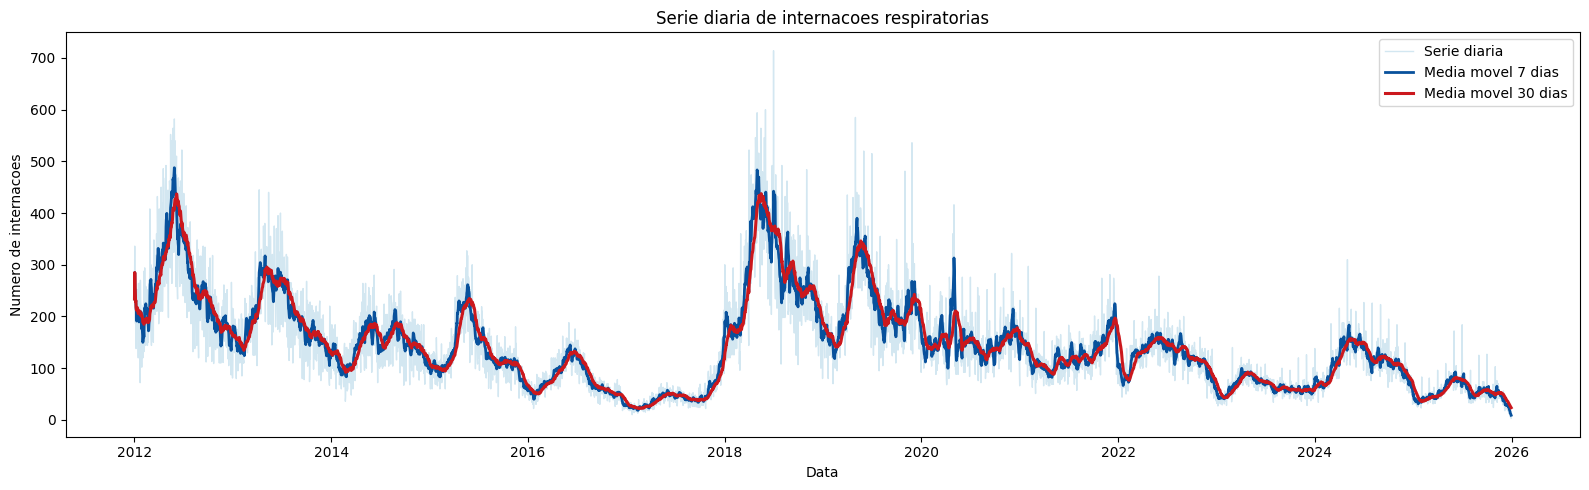

In [9]:
plt.figure(figsize=(16, 5))

plt.plot(
    df_serie["data_dia"],
    df_serie["num_internacoes"],
    color="#9ecae1",
    linewidth=1,
    alpha=0.45,
    label="Serie diaria"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_7d"],
    color="#08519c",
    linewidth=2,
    label="Media movel 7 dias"
)

plt.plot(
    df_serie["data_dia"],
    df_serie["mm_30d"],
    color="#cb181d",
    linewidth=2.2,
    label="Media movel 30 dias"
)

plt.title("Serie diaria de internacoes respiratorias")
plt.xlabel("Data")
plt.ylabel("Numero de internacoes")
plt.legend()
plt.tight_layout()
plt.show()

### Distribuicao dos valores

A serie temporal pode ter comportamento muito assimetrico. Por isso, alem do grafico no tempo, vale olhar a distribuicao dos valores diarios.

O histograma mostra onde a maior parte dos dias se concentra. O boxplot ajuda a ver a dispersao, a mediana e a presenca de valores extremos.

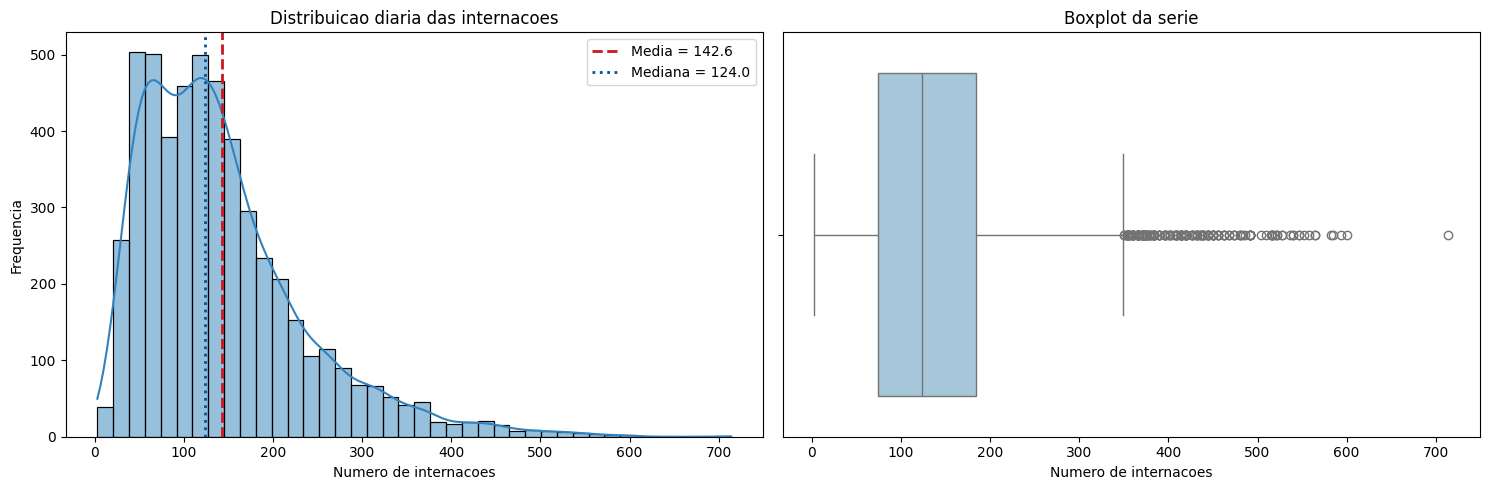

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_serie["num_internacoes"], bins=40, kde=True, color="#3182bd", ax=axes[0])
axes[0].axvline(
    df_serie["num_internacoes"].mean(),
    color="#cb181d",
    linestyle="--",
    linewidth=2,
    label=f"Media = {df_serie['num_internacoes'].mean():.1f}"
)
axes[0].axvline(
    df_serie["num_internacoes"].median(),
    color="#08519c",
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {df_serie['num_internacoes'].median():.1f}"
)
axes[0].set_title("Distribuicao diaria das internacoes")
axes[0].set_xlabel("Numero de internacoes")
axes[0].set_ylabel("Frequencia")
axes[0].legend()

sns.boxplot(x=df_serie["num_internacoes"], color="#9ecae1", ax=axes[1])
axes[1].set_title("Boxplot da serie")
axes[1].set_xlabel("Numero de internacoes")

plt.tight_layout()
plt.show()

### Resumo interpretativo dos resultados

A média esta em torno de **142,6 internacoes por dia**, mas a **mediana de 124** mostra que os dias mais tipicos ficam abaixo da media. 

A variabilidade da serie tambem é alta. O **desvio padrao foi 92,4**, o **IQR foi 110** e o **coeficiente de variacao ficou em 0,65**, o que sugere que a oscilacao diaria não é pequena em relação a média. Os percentis reforcam isso: **95% dos dias ficaram abaixo de 325 internacoes** e **99% abaixo de 450**, enquanto o valor maximo chegou a **714**. Portanto, a serie apresenta eventos extremos relevantes e nao apenas pequenas flutuacoes aleatorias.

Os maiores picos ficaram concentrados principalmente em **2012**, **2018** e **2019**, com destaque para varios dias entre **abril e julho de 2018**. Isso pode indicar mudancas de regime, ondas respiratorias mais intensas em periodos especificos ou ate alteracoes operacionais/de registro que precisam ser verificadas nas proximas etapas.

**Possiveis analises e consequencias**
- A diferenca entre media e mediana, junto da cauda a direita observada no histograma, sugere testar transformacoes como `log1p` antes da modelagem.
- A presenca de muitos valores extremos no boxplot indica que vale investigar outliers e dias de pico como eventos epidemiologicos, sazonais ou mudancas de notificacao.
- Como varios picos aparecem entre abril e julho, a proxima secao deve explorar sazonalidade anual e efeitos de calendario para separar padrao recorrente de eventos excepcionais.